In [711]:
!pip install --upgrade statsmodels
!pip install --upgrade pmdarima

In [712]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Task 1 specifics
from sklearn.model_selection import train_test_split #For splitting test and training data
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import adfuller #For Dickey Fuller test
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA #For ARIMA model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #plotting Autocorrelation
from statsmodels.tsa.stattools import acf #Extracts numerical values
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX




Data Dictionary:
The data set consists of 731 rows (days) and two columns or variables:
• Day: Day during first two years of operation
• Revenue: Revenue in million dollars

In [714]:
#Import Data
filename = 'teleco_time_series .csv'
df = pd.read_csv(filename)


Do exploratory data analysis with visualizations. Clean and prepare data.

In [716]:
print(df.head(10))

   Day   Revenue
0    1  0.000000
1    2  0.000793
2    3  0.825542
3    4  0.320332
4    5  1.082554
5    6  0.107654
6    7  0.493901
7    8  0.376698
8    9  0.304075
9   10  0.591748


In [717]:
print(df.duplicated().sum())

0


In [718]:
df.columns


Index(['Day', 'Revenue'], dtype='str')

In [719]:
df.shape
            

(731, 2)

In [720]:
print(df.isnull().sum())

Day        0
Revenue    0
dtype: int64


No missing values


In [722]:
print(df.describe())


              Day     Revenue
count  731.000000  731.000000
mean   366.000000    9.822901
std    211.165812    3.852645
min      1.000000    0.000000
25%    183.500000    6.872836
50%    366.000000   10.785571
75%    548.500000   12.566911
max    731.000000   18.154769


In [853]:
#Since no date has been established, the date will start at January 1st, 2023
df.index = pd.date_range(start='2023-01-01', periods=731, freq='D')
df.head()

,Revenue
2023-01-01,0.000000
2023-01-02,0.000793
2023-01-03,0.825542
2023-01-04,0.320332
2023-01-05,1.082554


In [857]:
print(df['Revenue'])

2023-01-01     0.000000
2023-01-02     0.000793
2023-01-03     0.825542
2023-01-04     0.320332
2023-01-05     1.082554
                ...    
2024-12-27    16.931559
2024-12-28    17.490666
2024-12-29    16.803638
2024-12-30    16.194813
2024-12-31    16.620798
Freq: D, Name: Revenue, Length: 731, dtype: float64


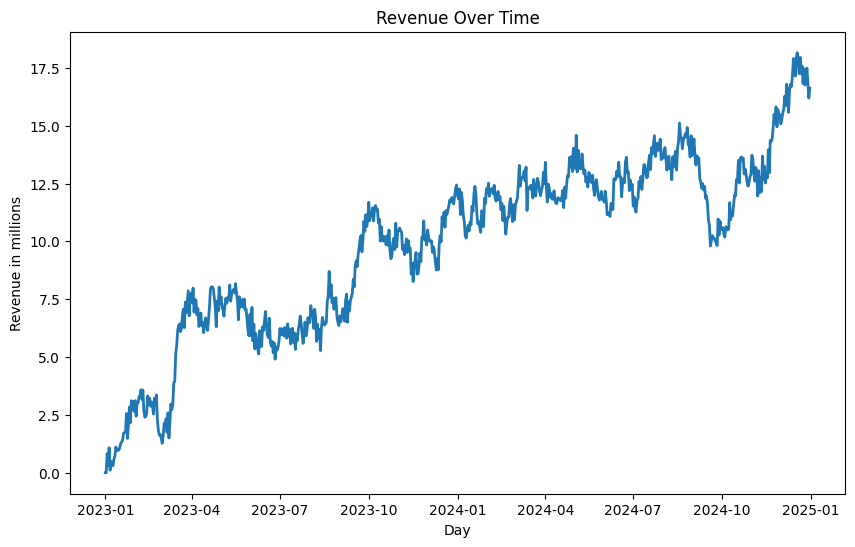

In [724]:
#Visualize the data with line plot for C1

plt.figure(figsize=(10,6))
plt.plot(df['Revenue'], linewidth = 2)
plt.title('Revenue Over Time')
plt.xlabel('Day')
plt.ylabel('Revenue in millions')
plt.show()

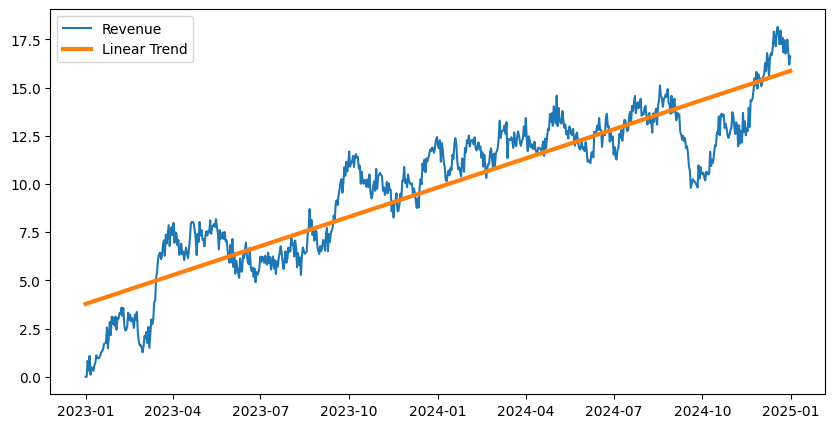

In [725]:
#Visualize with trend line

z = np.polyfit(range(len(df)), df['Revenue'], 1)

trend = np.poly1d(z)
plt.figure(figsize=(10,5))
plt.plot(df['Revenue'], label='Revenue')

plt.plot(
    df.index,
    trend(range(len(df))),
    label='Linear Trend',
    linewidth=3
)
plt.legend()
plt.show()

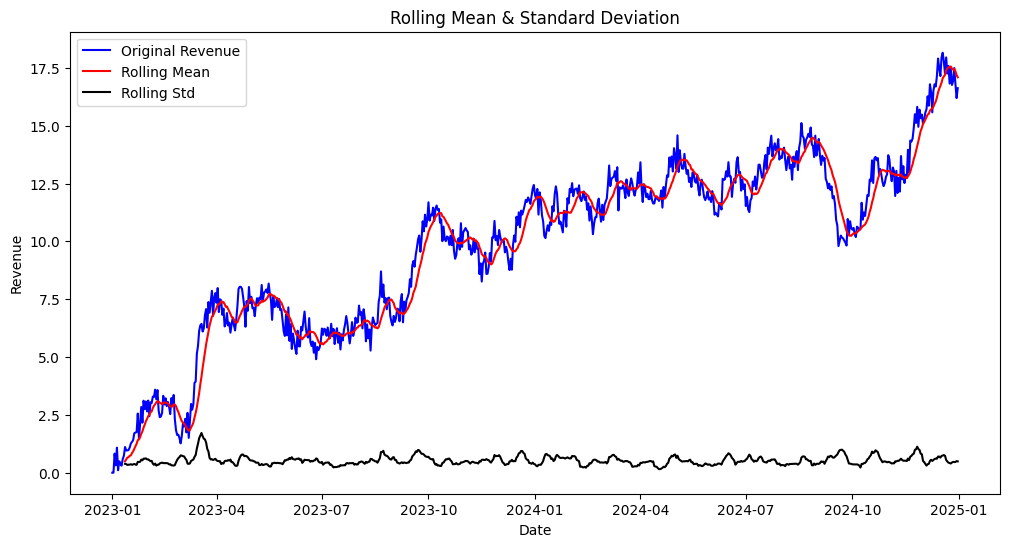

In [726]:
#Rolling mean graph to find data stationarity (Sewell, n.d.)
# Rolling Mean and Standard Deviation

# Calculate rolling statistics
rolmean = df['Revenue'].rolling(window=12).mean()
rolstd = df['Revenue'].rolling(window=12).std()

# Plot original data and rolling statistics
plt.figure(figsize=(12,6))

plt.plot(df['Revenue'], color='blue', label='Original Revenue')
plt.plot(rolmean, color='red', label='Rolling Mean')
plt.plot(rolstd, color='black', label='Rolling Std')

plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.show()

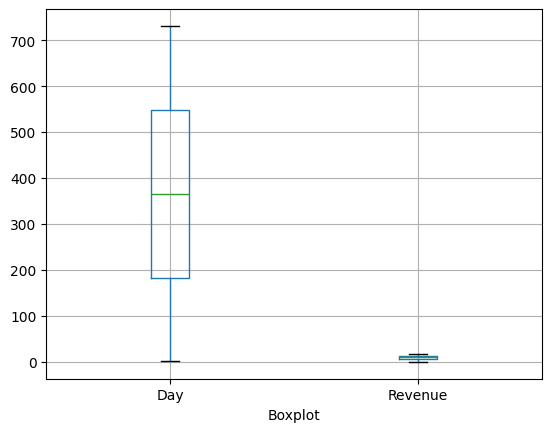

In [727]:
#Visualize by boxplot

df_bp = df.boxplot()
df_bp.set_xlabel('Boxplot')
plt.show()


<Axes: xlabel='Revenue'>

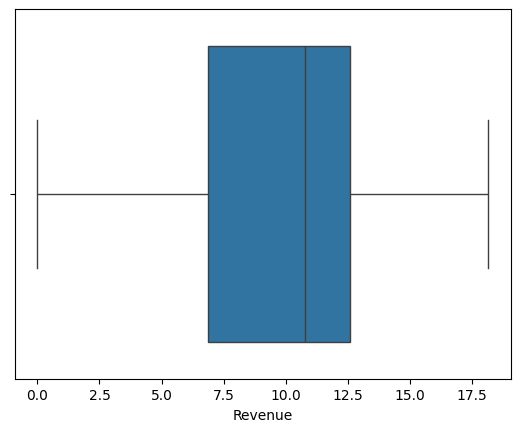

In [728]:
sns.boxplot(x='Revenue',data =df)

No Outliers

Clear upward trend
Does not fluctuate around a constant mean (not stationary)
Variance increase


Notes:
Trend is observed when there is increase / decrease in slope observed in time series
Seasonality is when Distinct repeated pattern at regular intervals


In [731]:
print(df.columns)
print(df.head())

Index(['Day', 'Revenue'], dtype='str')
            Day   Revenue
2023-01-01    1  0.000000
2023-01-02    2  0.000793
2023-01-03    3  0.825542
2023-01-04    4  0.320332
2023-01-05    5  1.082554


In [732]:
#Drop Days
df.drop('Day', axis=1, inplace=True)

In [733]:
df.columns
print(df.head())

             Revenue
2023-01-01  0.000000
2023-01-02  0.000793
2023-01-03  0.825542
2023-01-04  0.320332
2023-01-05  1.082554


In [734]:
print(df)
print(df.tail())

              Revenue
2023-01-01   0.000000
2023-01-02   0.000793
2023-01-03   0.825542
2023-01-04   0.320332
2023-01-05   1.082554
...               ...
2024-12-27  16.931559
2024-12-28  17.490666
2024-12-29  16.803638
2024-12-30  16.194813
2024-12-31  16.620798

[731 rows x 1 columns]
              Revenue
2024-12-27  16.931559
2024-12-28  17.490666
2024-12-29  16.803638
2024-12-30  16.194813
2024-12-31  16.620798


Notes:
Need to make the series stationary
Autoregressive forecasting models are essentialy linear regression models that utilize lag
basically Linear regression works best if predictors are not correlated
so stationarizing does that since it removes any persistent autocorrelation
making the lags (predictors) in the model nearly independent


"The most commonly used is the ADF test, where the null hypothesis is the time series possesses a unit root and is non-stationary. So, id the P-Value in ADH test is less than the significance level (0.05), you reject the null hypothesis."



In [736]:

#Do Dickey Fuller test to check if the data is stationary
#Test statistic needs to be more negative than critical value
#p value must be below 0.05 to reject null hypothesis aka state of non stationary


adf_test = adfuller(df['Revenue'])
print("P-Value: ", adf_test[1])

P-Value:  0.32057281507939783


Now Preprocess the data since we have confirmed that the data is not stationary and not fit for ARIMA modeling yet.
Differentiate the data


In [738]:
#Create a new dataframe that is diffed

dfd = df.diff()
print(dfd.head())

             Revenue
2023-01-01       NaN
2023-01-02  0.000793
2023-01-03  0.824749
2023-01-04 -0.505210
2023-01-05  0.762222


In [739]:
#Remnove the NAN because the first value cannot be differentiated

dfd = dfd.dropna()

In [740]:
print(dfd.head())

             Revenue
2023-01-02  0.000793
2023-01-03  0.824749
2023-01-04 -0.505210
2023-01-05  0.762222
2023-01-06 -0.974900


In [741]:
#Check for P-value via adfuller again

adf_test2 = adfuller(dfd['Revenue'])
print("P-Value: ", adf_test2[1])

P-Value:  0.0


P-Value shows that it is now stationary


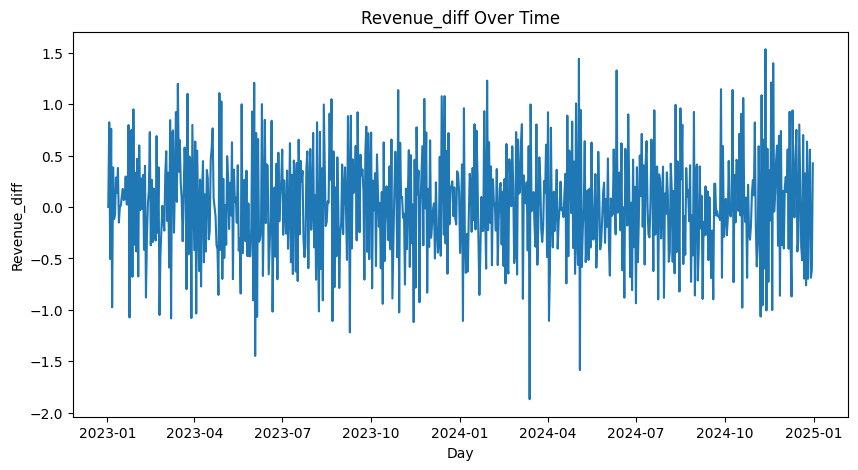

In [743]:
#Need a visual plot to confirm it is stationary visually

#Visualize the data

plt.figure(figsize=(10,5))
plt.plot(dfd['Revenue'])
plt.title('Revenue_diff Over Time')
plt.xlabel('Day')
plt.ylabel('Revenue_diff')
plt.show()

In [845]:
#Split the data, Original data 

train, test = train_test_split(df, test_size = 0.2, shuffle = False, random_state = 1)
print(train)
print(test)

              Revenue
2023-01-01   0.000000
2023-01-02   0.000793
2023-01-03   0.825542
2023-01-04   0.320332
2023-01-05   1.082554
...               ...
2024-08-02  13.938920
2024-08-03  14.052184
2024-08-04  13.520478
2024-08-05  13.082643
2024-08-06  13.504886

[584 rows x 1 columns]
              Revenue
2024-08-07  13.684826
2024-08-08  13.152903
2024-08-09  13.310290
2024-08-10  12.665601
2024-08-11  13.660658
...               ...
2024-12-27  16.931559
2024-12-28  17.490666
2024-12-29  16.803638
2024-12-30  16.194813
2024-12-31  16.620798

[147 rows x 1 columns]


In [849]:

#Train Date start and end

print(train)


              Revenue
2023-01-01   0.000000
2023-01-02   0.000793
2023-01-03   0.825542
2023-01-04   0.320332
2023-01-05   1.082554
...               ...
2024-08-02  13.938920
2024-08-03  14.052184
2024-08-04  13.520478
2024-08-05  13.082643
2024-08-06  13.504886

[584 rows x 1 columns]


In [851]:
#Test Date start and end
print(test)

              Revenue
2024-08-07  13.684826
2024-08-08  13.152903
2024-08-09  13.310290
2024-08-10  12.665601
2024-08-11  13.660658
...               ...
2024-12-27  16.931559
2024-12-28  17.490666
2024-12-29  16.803638
2024-12-30  16.194813
2024-12-31  16.620798

[147 rows x 1 columns]


Data is now split 80 to 20.
80 for training
20 for testing



In [746]:
print(df.shape)

(731, 1)


In [747]:
#Double Check to see if the split is successful and proportional
print( 0.8 * 731)

584.8000000000001


ARIMA PDF
D = 1
for differencing once in order to be stationary


In [749]:
#Export the clean data C5
df.to_csv('C5_Clean_Data_Pre_Differecing_Submittable.csv')
dfd.to_csv('C5_Clean_Data_Post_Differencing_Ssubmitatble.csv')
train.to_csv('C5_D213_task_1_Train_data_Submittable.csv')
test.to_csv('C5_D213_task_1_Test_data_Submittable.csv')

D1. Seasonal_decompose


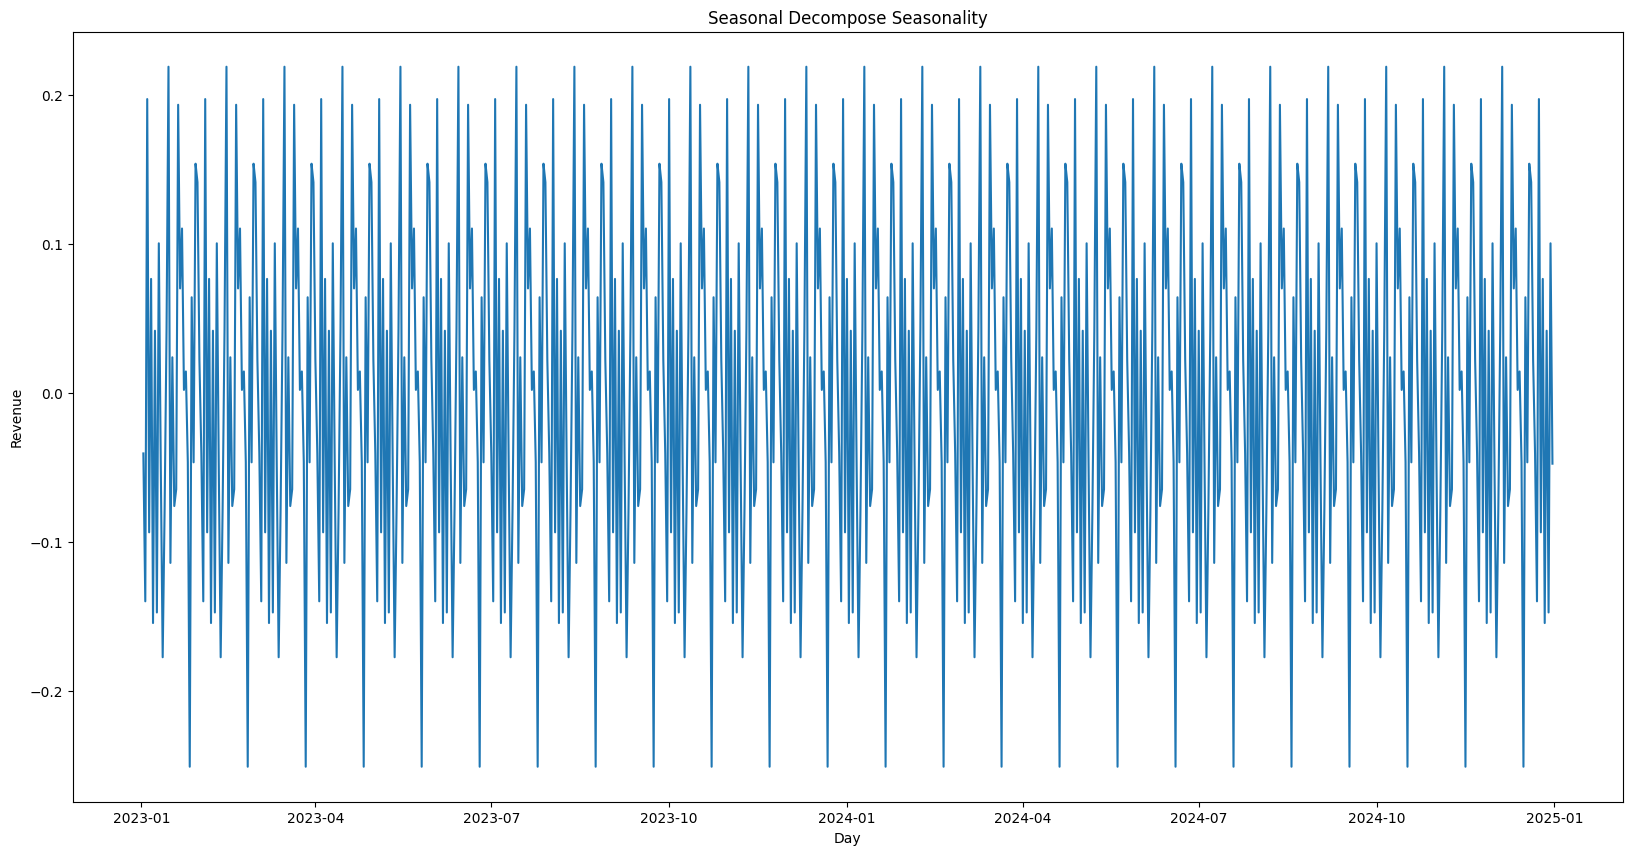

In [751]:
#Use seasonal_decompose to check for seasonality component

result_mul = seasonal_decompose(dfd['Revenue'], model = 'additive', period = 30)
plt.figure(figsize=(20,10))
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.title("Seasonal Decompose Seasonality")
plt.plot(result_mul.seasonal)
plt.show()

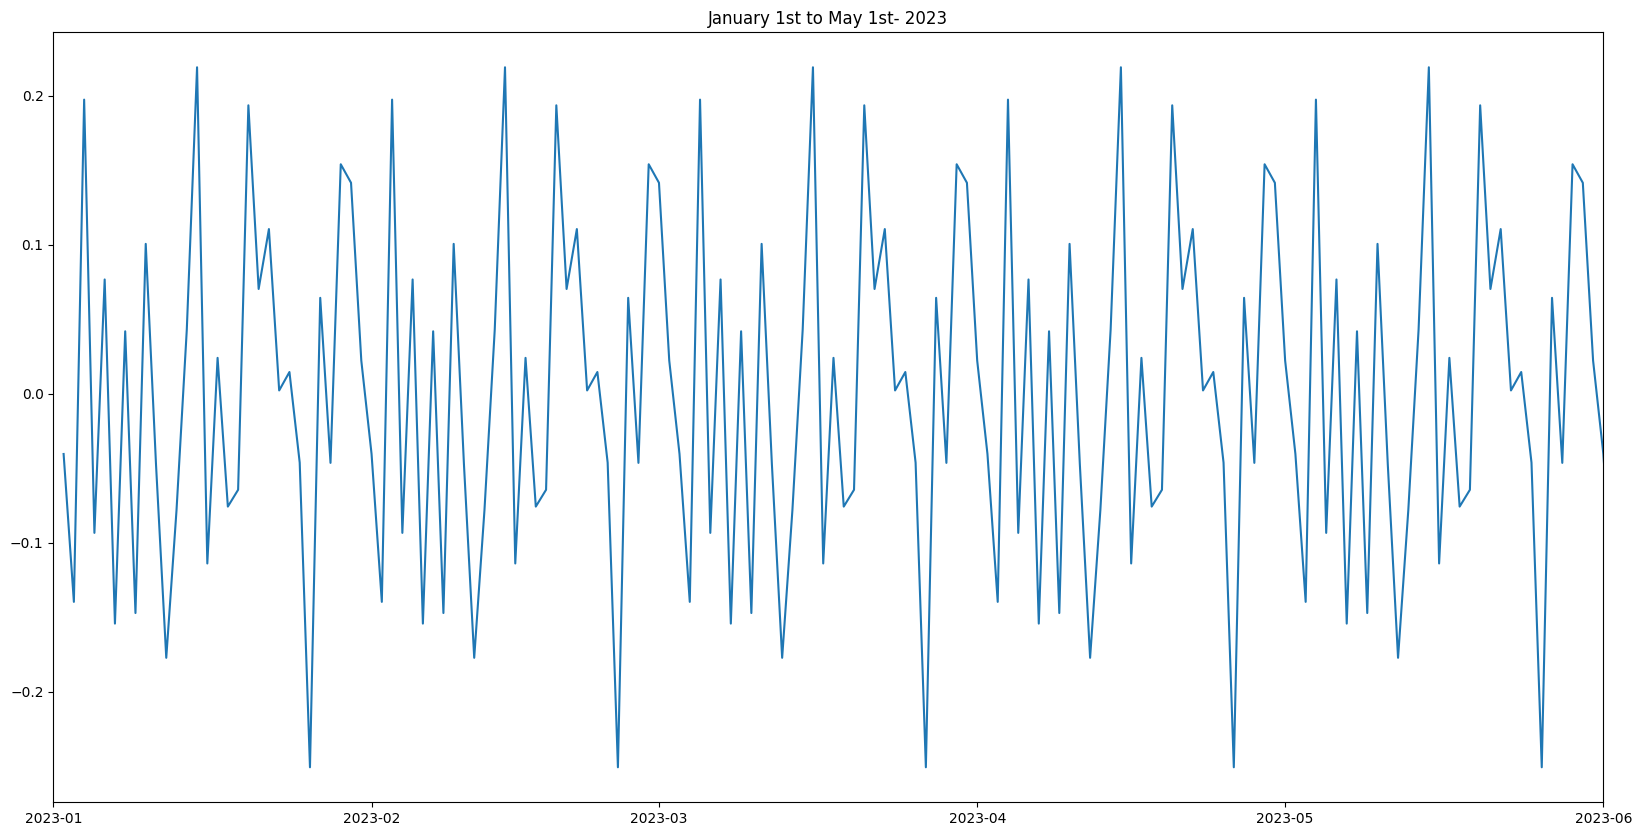

In [752]:
#Look up close, maybe do 6 moonths? 

plt.figure(figsize = (20,10))
plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-06-01'))
plt.plot(result_mul.seasonal)
plt.title("January 1st to May 1st- 2023")
plt.show()


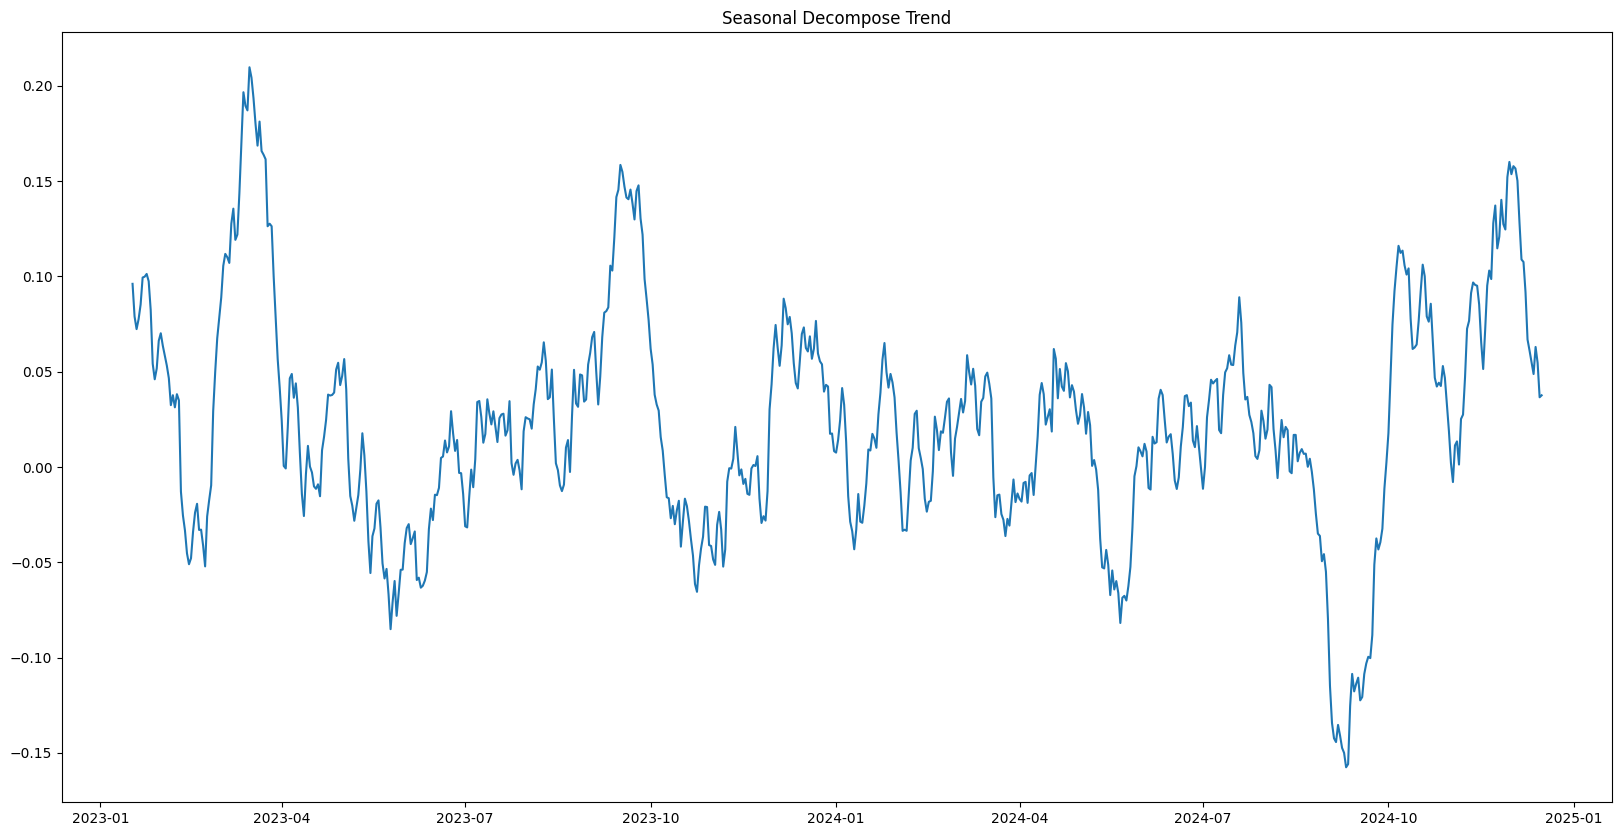

In [753]:
#Plot Trends

plt.figure(figsize = (20,10))
plt.plot(result_mul.trend)
plt.title("Seasonal Decompose Trend")
plt.show()

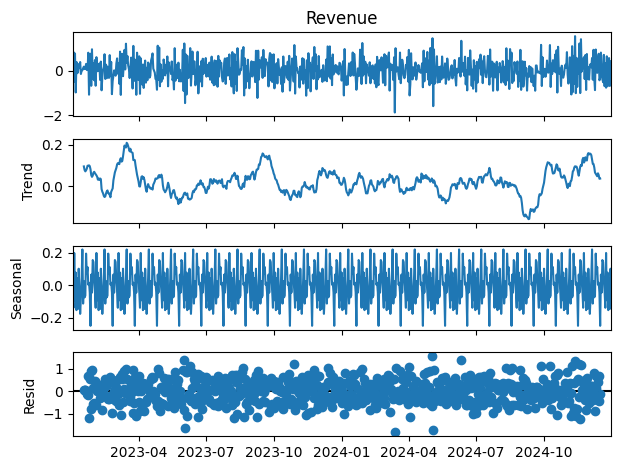

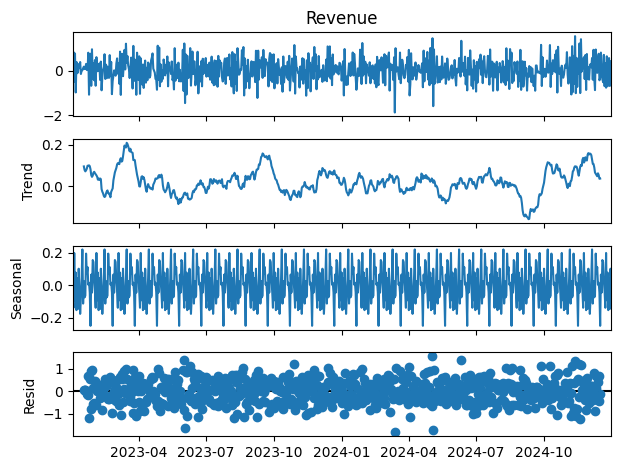

In [754]:

result_mul.plot()

Autocorrelation


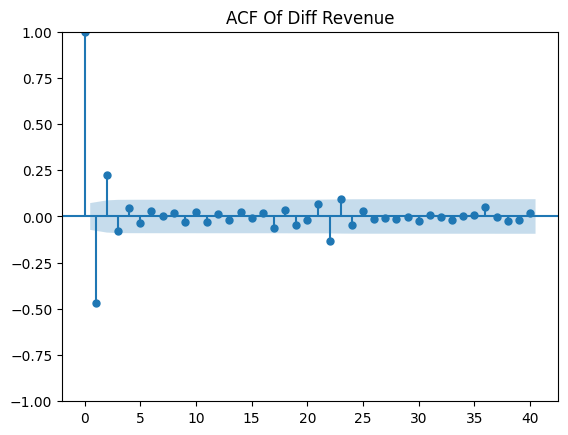

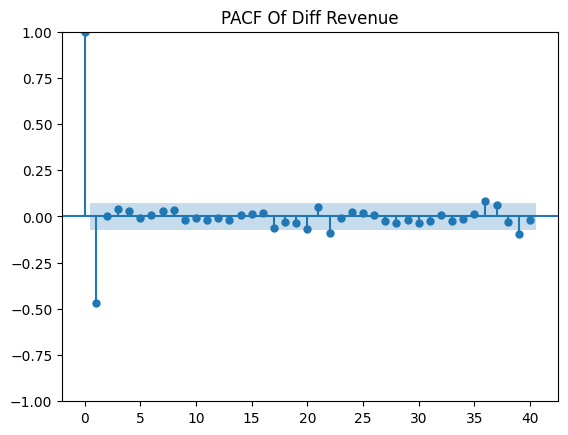

In [756]:
#Do autocorrelation, probably do both for differenced and original data

#This one is for the differenced data

plot_acf(dfd['Revenue'], lags=40,alpha=0.05)
plt.title("ACF Of Diff Revenue")
plt.show()

plot_pacf(dfd['Revenue'], lags=40,alpha=0.05)
plt.title("PACF Of Diff Revenue")
plt.show()

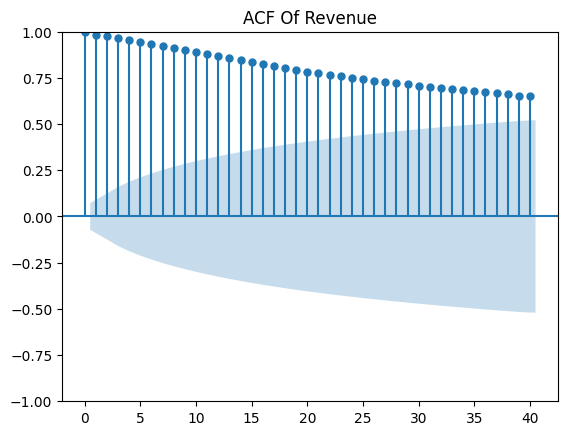

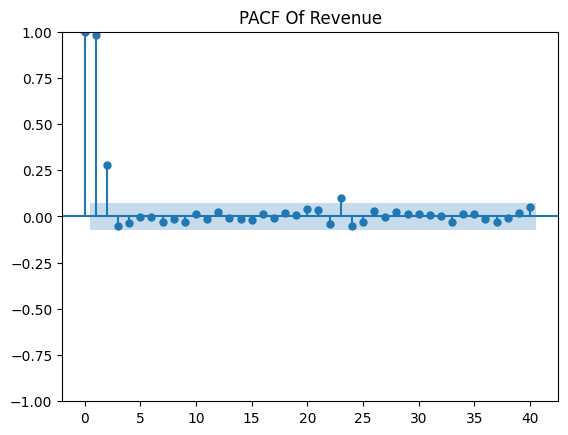

In [757]:

plot_acf(df['Revenue'], lags=40,alpha=0.05)
plt.title("ACF Of Revenue")
plt.show()

plot_pacf(df['Revenue'], lags=40,alpha=0.05)
plt.title("PACF Of Revenue")
plt.show()

PDQ:


P = Number of lag in obseravation of Autoregression

D = Number of times of differencing to make the data stationary


Professor Aly notes:

“If the ACF drops sharply to zero after lag k, that suggests an MA(k) model.”

ACF of diffeded data, q = 1



PDQ =  (1,1,2)

1 for PACF
1 for differecing once
2 for the two lag spikes in ACF

(array([0.02187272, 0.06794442, 0.10193972, 0.03234469, 0.04559398,
        0.14815969, 0.19015645, 0.13556855, 0.17930696, 0.08735005,
        0.19447871, 0.13755823, 0.01020268, 0.09512023, 0.18805592,
        0.24517453, 0.20614533, 0.18171205, 0.06867317, 0.08851738,
        0.15697924, 0.11499682, 0.30811184, 0.14944065, 0.05001068,
        0.07531453, 0.07789058, 0.01673615, 0.21814643, 0.26177285,
        0.12608986, 0.26308319, 0.16121103, 0.04795751, 0.1613957 ,
        0.04902511, 0.26613974, 0.16274877, 0.10082987, 0.14421741,
        0.15131872, 0.10587624, 0.21235552, 0.28259121, 0.03221009,
        0.01834018, 0.04559876, 0.07659406, 0.05610271, 0.08696616,
        0.22968462, 0.1827402 , 0.09436169, 0.0237871 , 0.21783212,
        0.18875707, 0.06917957, 0.13361489, 0.06783029, 0.08269334,
        0.03112555, 0.02422832, 0.13926167, 0.39890482, 0.08670748,
        0.11441993, 0.11177872, 0.18740897, 0.12808631, 0.06475304,
        0.0077952 , 0.06857082, 0.24922119, 0.16

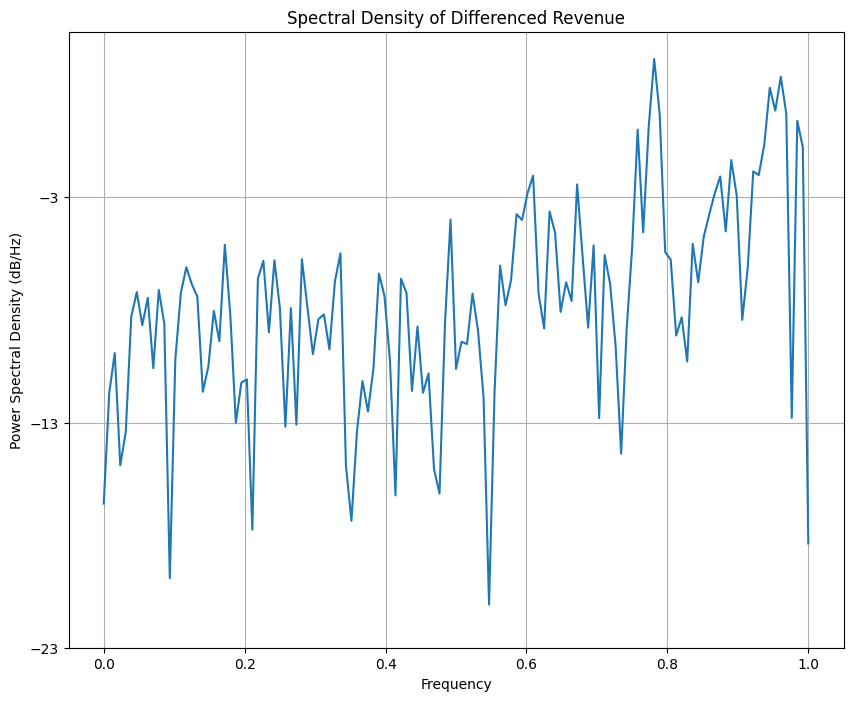

In [759]:
#Do Spectral Density graph
plt.figure(figsize = (10,8))
plt.title("Spectral Density of Differenced Revenue")
plt.xlabel("Frequency")
plt.ylabel("Power Spectral Density")
plt.psd(dfd['Revenue'])



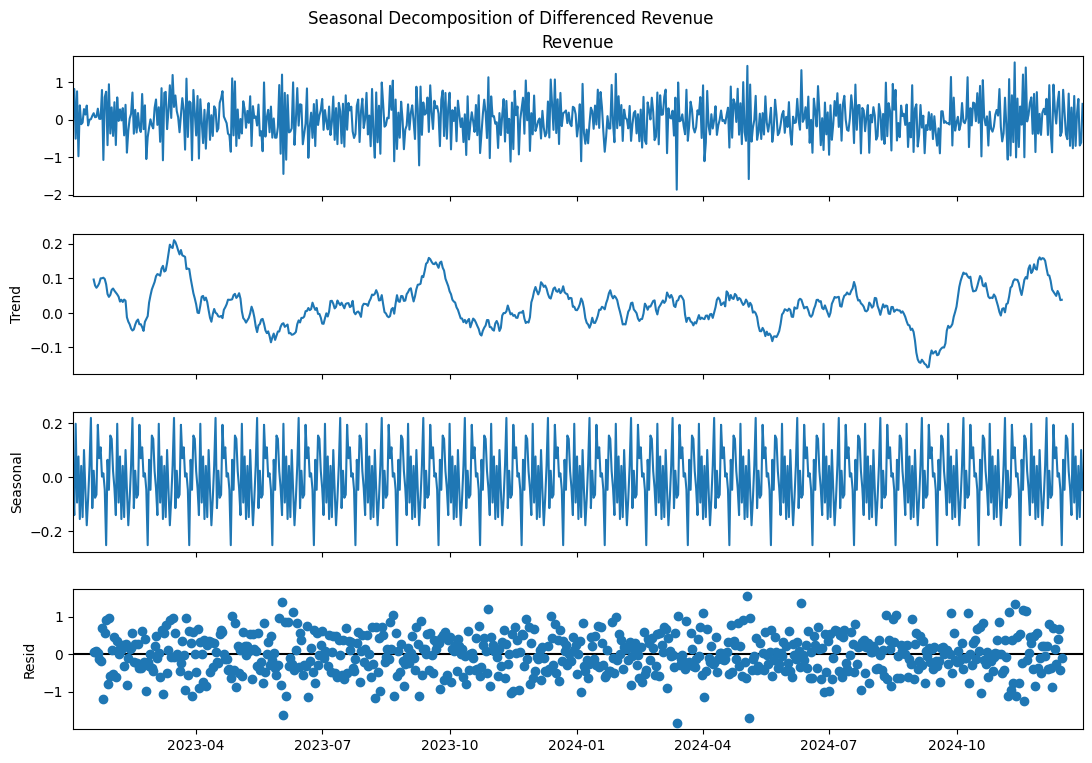

In [760]:
#Redo decomposed time series since the first one looks terrible

fig = result_mul.plot()
fig.set_size_inches(12,8)

plt.suptitle("Seasonal Decomposition of Differenced Revenue")
plt.show()

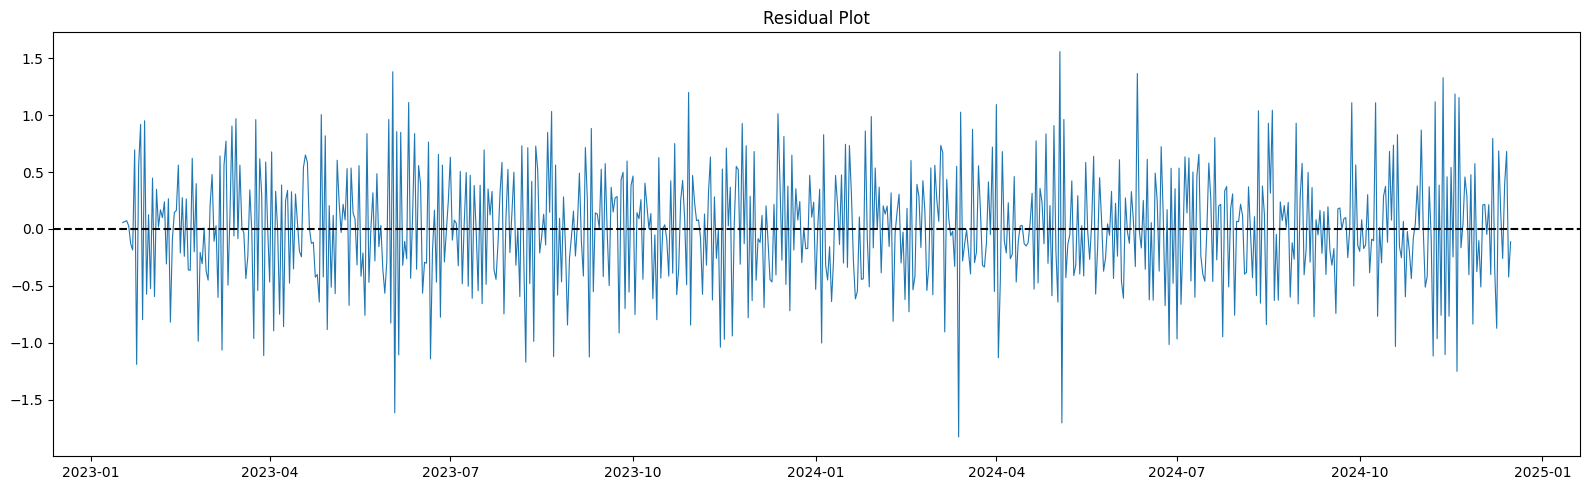

In [761]:
#Do a residual plot to show lack of trends

plt.figure(figsize=(16,5))
plt.plot(result_mul.resid, linewidth=0.8)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

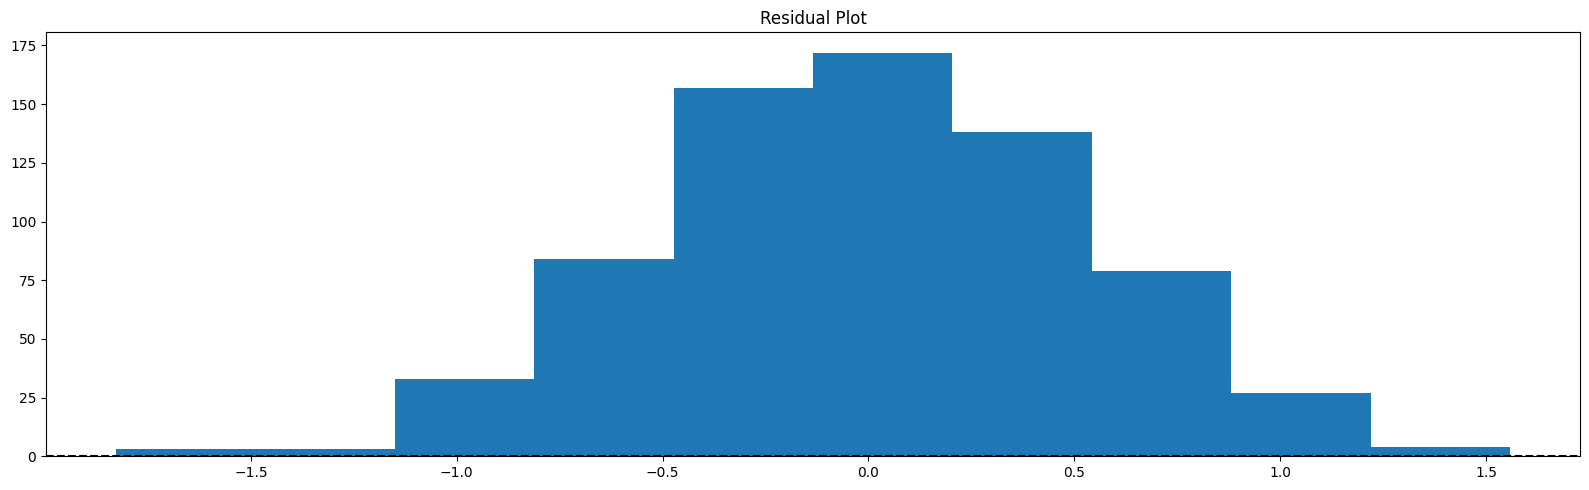

In [762]:
#Do a residual plot to show lack of trends

plt.figure(figsize=(16,5))
plt.hist(result_mul.resid, linewidth=0.8)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

Make Arima
Initial PDQ Values with Dr Aly's preferred interpretation of choosing the P and Q value
(1,1,2)


Use Original non-differenced data as ARIMA can handle it (Aly, n.d.)




In [764]:
# Create ARIMA(1,1,2) model


arima1 = ARIMA(df['Revenue'], order=(1,1,2), freq='D')

# Fit model
arima1_result = arima1.fit()

# Display AIC
print("arima1_result :", arima1_result.aic)
print("arima1_result summary:", arima1_result.summary())

arima1_result : 986.8180892042399
arima1_result summary:                                SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  731
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -489.409
Date:                Sun, 07 Jun 2026   AIC                            986.818
Time:                        08:08:40   BIC                           1005.190
Sample:                    01-01-2023   HQIC                           993.906
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2795      0.154     -1.820      0.069      -0.581       0.022
ma.L1         -0.1854      0.155     -1.199      0.231      -0.489       0

USE AIC AND BIC AS metrics


In [766]:
#Do autoArima
stepwise_fit = auto_arima(df['Revenue'], trace =True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=987.305, Time=0.39 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1162.819, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=983.122, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1019.369, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1162.139, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=985.104, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=985.106, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=986.045, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=984.710, Time=0.02 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.915 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  731
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -488.561
Date:                Sun, 07 Jun 2026   AIC                            983.122
Time:                        08:08:40   BIC                            996.901
Sample:                    01-01-2023   HQIC                           988.438
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0332      0.018      1.895      0.058      -0.001       0.068
ar.L1         -0.4692      0.033    -14.296      0.000      -0.534      -0.405
sigma2         0.2232      0.013     17.801      0.000       0.199       0.248
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.05
Prob(Q):                              0.96   Prob(JB):                         0.36
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.85   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""


AutoArima will run a Sarimax anyway because it is a robust algorithm


second set of parenthesese (0,0,0) means no seasonality which is good (Dr.Sewell ,n.d.)


arima1  = AIC: 986, BIC: 1005

Auto_arima = AIC: 983, BIC: 996

Arima1 pdq:  1,1,2

Autoarima pdq: 1,1,0


Okay let's bridge the graph and do 1,1,1 for curiosity


In [770]:
# Create ARIMA(1,1,1) model


arima2 = ARIMA(df['Revenue'], order=(1,1,1), freq='D')

# Fit model
arima2_result = arima2.fit()

# Display AIC
print("arima2_result :", arima2_result.aic)
print("arima2_result summary:", arima2_result.summary())

arima2_result : 986.6517104362356
arima2_result summary:                                SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  731
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -490.326
Date:                Sun, 07 Jun 2026   AIC                            986.652
Time:                        08:08:41   BIC                           1000.431
Sample:                    01-01-2023   HQIC                           991.968
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4804      0.068     -7.063      0.000      -0.614      -0.347
ma.L1          0.0176      0.077      0.227      0.821      -0.134       0

In [771]:
# Create ARIMA(1,1,0) model


arima3 = ARIMA(df['Revenue'], order=(1,1,0), freq='D')

# Fit model
arima3_result = arima3.fit()

# Display AIC
print("arima2_result :", arima3_result.aic)
print("arima2_result summary:", arima3_result.summary())

arima2_result : 984.7100557719148
arima2_result summary:                                SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  731
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -490.355
Date:                Sun, 07 Jun 2026   AIC                            984.710
Time:                        08:08:41   BIC                            993.896
Sample:                    01-01-2023   HQIC                           988.254
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4667      0.033    -14.213      0.000      -0.531      -0.402
sigma2         0.2243      0.013     17.782      0.000       0.200       0

arima1  = AIC: 986, BIC: 1005

Auto_arima = AIC: 983, BIC: 996

arima2 = AIC: 986, BIC: 1000

Arima1 pdq:  1,1,2

Autoarima pdq: 1,1,0


Arima2 pdq: 1,1,1


Okay so it does look like Autoarima worked correctly.


In [774]:
#Do ARIMA with split dataset
#PDQ ( 1,1,0 ) for best stats

#should be 80/20 split
print(train.shape)
print(test.shape)
print(train.columns)



(584, 1)
(147, 1)
Index(['Revenue'], dtype='str')


In [775]:
print(train.index.min())
print(train.index.max())

print(test.index.min())
print(test.index.max())

2023-01-01 00:00:00
2024-08-06 00:00:00
2024-08-07 00:00:00
2024-12-31 00:00:00


In [776]:
#Make model

model = ARIMA(train['Revenue'], order= (1,1,0))
model = model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                  584
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -385.018
Date:                Sun, 07 Jun 2026   AIC                            774.035
Time:                        08:08:41   BIC                            782.772
Sample:                    01-01-2023   HQIC                           777.441
                         - 08-06-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4578      0.036    -12.618      0.000      -0.529      -0.387
sigma2         0.2193      0.014     15.954      0.000       0.192       0.246
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.81
Prob(Q):                              0.91   Prob(JB):                         0.40
Heteroskedasticity (H):               0.97   Skew:                            -0.07
Prob(H) (two-sided):                  0.81   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [777]:
# Make predictions on test set

start = len(train)
end = len(train) + len(test) - 1

pred = model.predict(start=start, end=end, typ='levels')

# Match prediction index to test dates
pred.index = test.index

print(pred)

2024-08-07    13.311586
2024-08-08    13.400077
2024-08-09    13.359566
2024-08-10    13.378112
2024-08-11    13.369622
                ...    
2024-12-27    13.372288
2024-12-28    13.372288
2024-12-29    13.372288
2024-12-30    13.372288
2024-12-31    13.372288
Freq: D, Name: predicted_mean, Length: 147, dtype: float64


C:\Users\nam\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


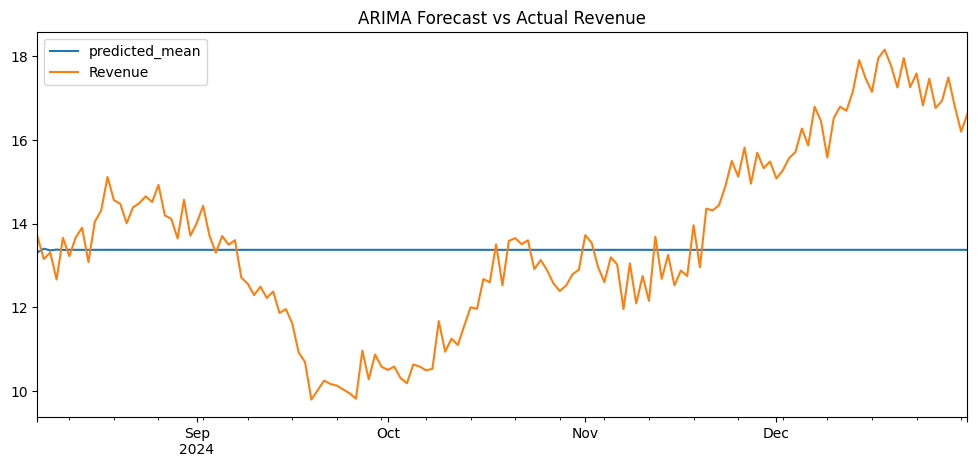

In [778]:
#Get Mean line (Sewell)

pred.plot(legend=True, figsize=(12,5))
test['Revenue'].plot(legend=True)

plt.title("ARIMA Forecast vs Actual Revenue")
plt.show()

In [779]:
# Forecast on test set
fc_test = model.get_forecast(steps=len(test))
fc_mean = fc_test.predicted_mean
fc_ci = fc_test.conf_int()

# Match forecast index with test index
fc_mean.index = test.index
fc_ci.index = test.index

mae = mean_absolute_error(test['Revenue'], fc_mean)
mse = mean_squared_error(test['Revenue'], fc_mean)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 1.738607878329873
MSE: 4.737181349875626
RMSE: 2.1765066850059585


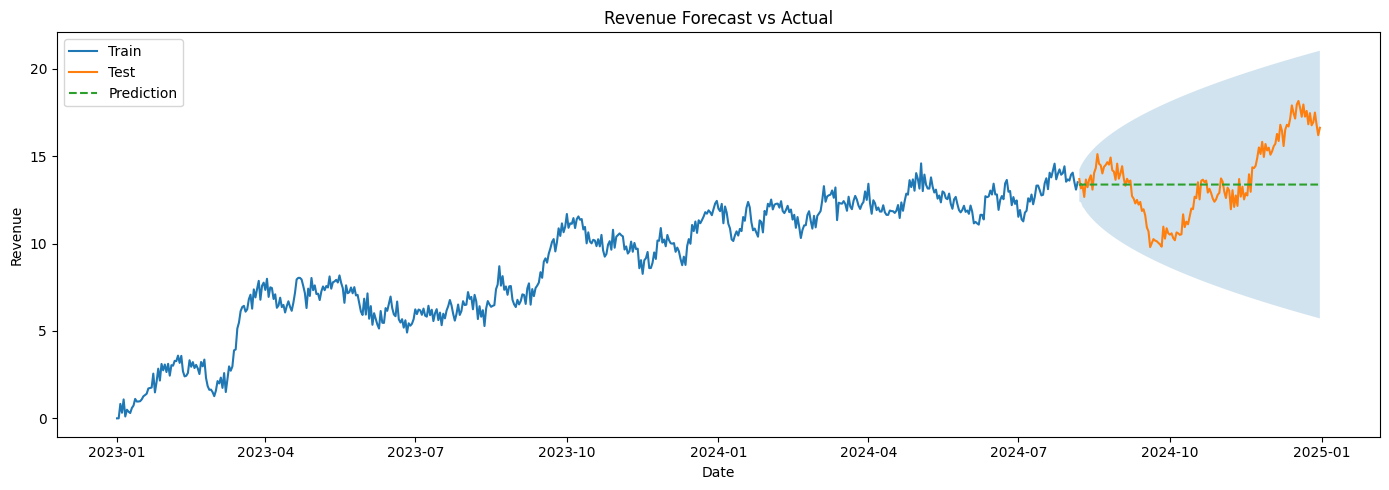

In [780]:
#Graph the forecast

plt.figure(figsize=(14,5))

plt.plot(train['Revenue'], label='Train')
plt.plot(test['Revenue'], label='Test')
plt.plot(fc_mean, label='Prediction', linestyle='--')

plt.fill_between(test.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2)

plt.title("Revenue Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.show()

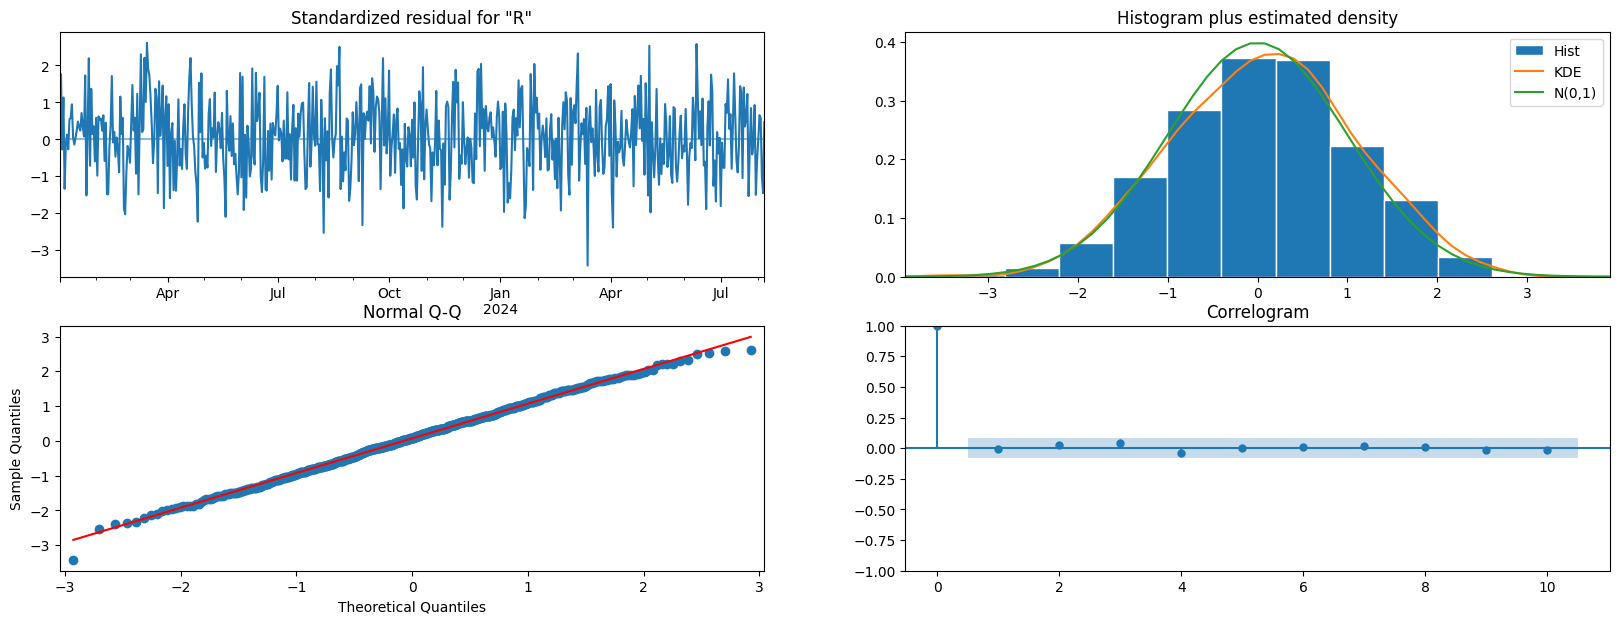

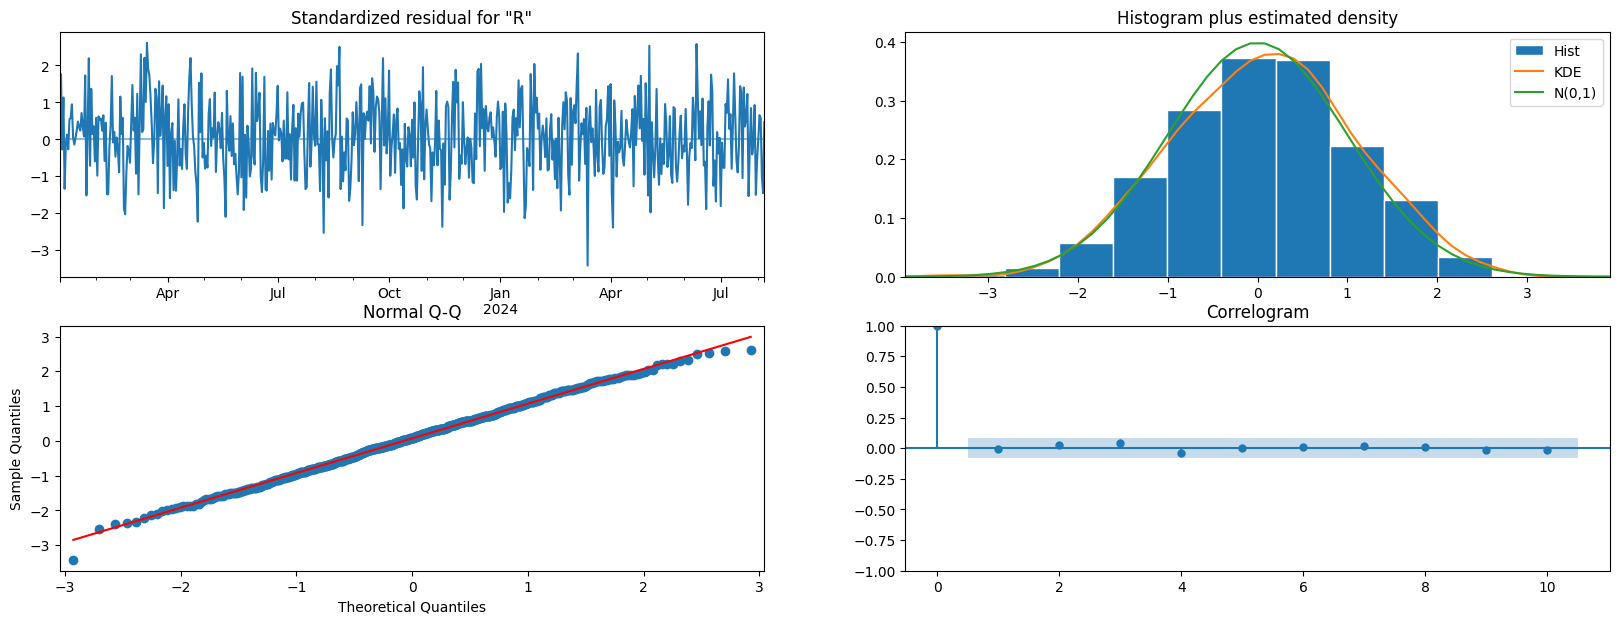

In [781]:
#Plot diagnostics 

model.plot_diagnostics(figsize=(20,7))

In [782]:
#More metrics


average_test = test['Revenue'].mean()

print("Average test revenue:", average_test)
print("RMSE:", rmse)



Average test revenue: 13.645083573503403
RMSE: 2.1765066850059585


RMSE is kind of like variance (Sewell, ARIMA 1)

So average of test values is 13.64, we have a margin of error of -+ 2.17 million


In [784]:
# Forecast the next 147 days after the dataset ends
#Revise 

# Train ARIMA model on the full dataset
final_model = ARIMA(df['Revenue'], order=(1,1,0))
final_model = final_model.fit()

future_dates = pd.date_range(start='2025-01-01', periods=147, freq='D')

future_forecast = final_model.get_forecast(steps=147)


future_values = future_forecast.predicted_mean

future_values.index = future_dates

print(future_values)




2025-01-01    16.422010
2025-01-02    16.514776
2025-01-03    16.471486
2025-01-04    16.491688
2025-01-05    16.482261
                ...    
2025-05-23    16.485260
2025-05-24    16.485260
2025-05-25    16.485260
2025-05-26    16.485260
2025-05-27    16.485260
Freq: D, Name: predicted_mean, Length: 147, dtype: float64


<Axes: title={'center': 'Revenue prediction 147 days after dataset'}, xlabel='Days after end of dataset', ylabel='Revenue in millions'>

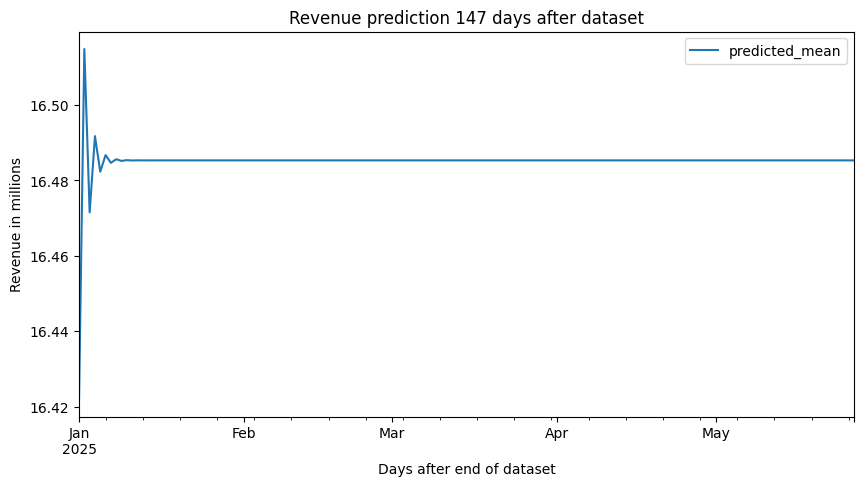

In [785]:
plt.figure(figsize=(10,5))
plt.title('Revenue prediction 147 days after dataset')
plt.xlabel('Days after end of dataset')
plt.ylabel('Revenue in millions')
future_values.plot(legend=True)

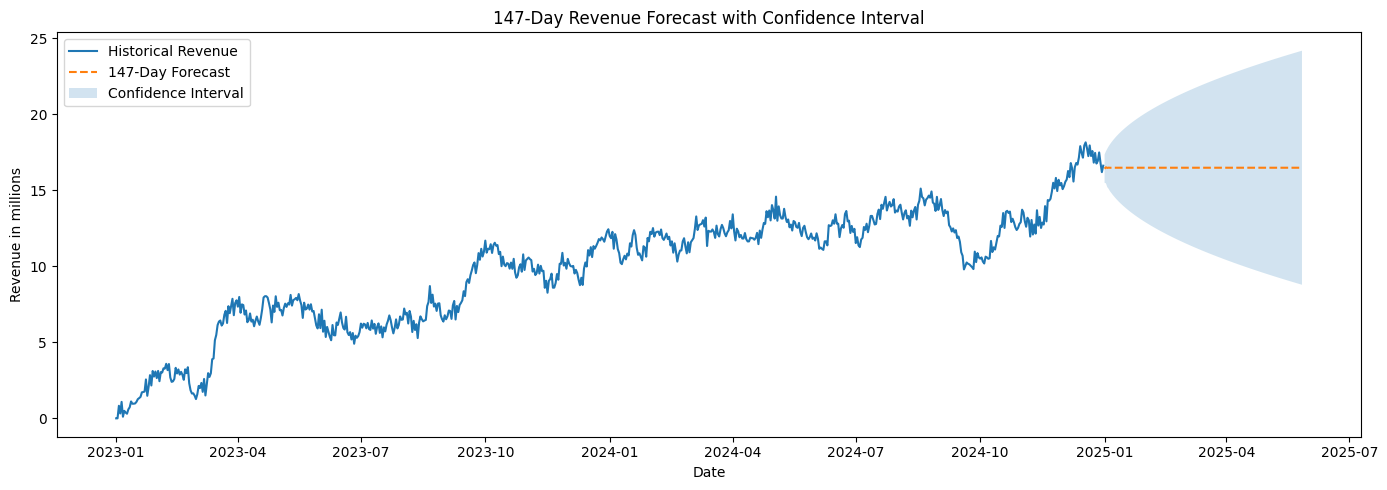

In [786]:
# Graph the future forecast with confidence interval
# Revised

plt.figure(figsize=(14,5))

# Plot the full original dataset
plt.plot(df['Revenue'], label='Historical Revenue')

# Get confidence interval for the 147-day forecast
future_ci = future_forecast.conf_int()
future_ci.index = future_dates

# Plot future forecast
plt.plot(future_values, label='147-Day Forecast', linestyle='--')

# Plot confidence interval
plt.fill_between(
    future_dates,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    label='Confidence Interval'
)

plt.title('147-Day Revenue Forecast with Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Revenue in millions')
plt.legend()

plt.tight_layout()
plt.show()